# Sequence similarity network from a FASTA file

This notebook builds a **sequence similarity network (SSN)** from a protein FASTA file. Each sequence is a node, each edge represents pairwise similarity above a user-defined threshold, and the resulting graph provides a direct view of local neighborhoods in sequence space.

The default input is `kras_homologs_10.fasta`, but the same workflow can be used with any homologous protein FASTA file.


## Method

Let $S_1,\dots,S_n$ be the protein sequences in the FASTA file. For every pair $(i,j)$, the notebook computes a normalized alignment similarity
\[
w_{ij}=
rac{A(S_i,S_j)}{\sqrt{A(S_i,S_i)\,A(S_j,S_j)}},
\]
where $A(\cdot,\cdot)$ is the global alignment score returned by `Biopython PairwiseAligner` using **BLOSUM62** and affine gap penalties.

Given a similarity threshold $	au$, the SSN is the weighted graph
\[
G_	au=(V,E_	au), \qquad V=\{1,\dots,n\},
\]
with
\[
(i,j)\in E_	au \iff w_{ij}\ge 	au.
\]
The edge weight is $w_{ij}$ itself. Increasing $	au$ reveals finer-grained neighborhoods; decreasing $	au$ merges them into larger connected components.

The layout is computed with a force-directed algorithm (`networkx.spring_layout`), which is useful for visualization but should not be interpreted as a metric embedding or a phylogenetic reconstruction.


## Requirements

This notebook uses `Biopython`, `networkx`, `numpy`, and `matplotlib`. If needed, install missing packages with:

```python
%pip install biopython networkx matplotlib
```


In [2]:
from pathlib import Path
from itertools import combinations
import csv
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from Bio import SeqIO
from Bio.Align import PairwiseAligner, substitution_matrices

INPUT_FASTA = Path('kras_homologs_10.fasta')
OUTPUT_PREFIX = Path('kras_ssn')
FIGURES_DIR = Path('../figures')
OUTPUT_PNG = FIGURES_DIR / 'sequenceTols_kras_ssn.png'
OUTPUT_PDF = FIGURES_DIR / 'sequenceTols_kras_ssn.pdf'
NODE_CSV = Path(f'{OUTPUT_PREFIX.name}_nodes.csv')
EDGE_CSV = Path(f'{OUTPUT_PREFIX.name}_edges.csv')
SIMILARITY_THRESHOLD = 0.88

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ALIGNER = PairwiseAligner(mode='global')
ALIGNER.substitution_matrix = substitution_matrices.load('BLOSUM62')
ALIGNER.open_gap_score = -10.0
ALIGNER.extend_gap_score = -0.5

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


In [3]:
def load_records(path: Path):
    records = list(SeqIO.parse(path, 'fasta'))
    if not records:
        raise ValueError(f'No FASTA records found in {path}')
    return records


def alignment_score(seq_a: str, seq_b: str) -> float:
    return float(ALIGNER.score(seq_a, seq_b))


def normalized_similarity(seq_a: str, seq_b: str) -> float:
    score_ab = alignment_score(seq_a, seq_b)
    score_aa = alignment_score(seq_a, seq_a)
    score_bb = alignment_score(seq_b, seq_b)
    scale = math.sqrt(max(score_aa, 1e-12) * max(score_bb, 1e-12))
    similarity = score_ab / scale
    return max(0.0, min(1.0, similarity))


def write_csv(path: Path, rows, fieldnames):
    with path.open('w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def short_label(record_id: str) -> str:
    return record_id.split()[0].replace('KRAS_', '').replace('_P', '\nP')


In [4]:
records = load_records(INPUT_FASTA)
ids = [record.description for record in records]
sequences = [str(record.seq) for record in records]

similarity_matrix = np.eye(len(records), dtype=float)
edge_rows = []
G = nx.Graph()

for record in records:
    G.add_node(record.description)

for (i, record_i), (j, record_j) in combinations(enumerate(records), 2):
    similarity = normalized_similarity(str(record_i.seq), str(record_j.seq))
    similarity_matrix[i, j] = similarity
    similarity_matrix[j, i] = similarity
    if similarity >= SIMILARITY_THRESHOLD:
        G.add_edge(record_i.description, record_j.description, weight=similarity)
        edge_rows.append({
            'source': record_i.description,
            'target': record_j.description,
            'similarity': float(similarity),
        })

components = list(nx.connected_components(G))
component_index = {}
for idx, component in enumerate(components, start=1):
    for node in component:
        component_index[node] = idx

node_rows = []
for node in G.nodes():
    degree = G.degree(node)
    weighted_degree = sum(data['weight'] for _, _, data in G.edges(node, data=True))
    node_rows.append({
        'node': node,
        'component': component_index[node],
        'degree': degree,
        'weighted_degree': float(weighted_degree),
    })

write_csv(NODE_CSV, node_rows, ['node', 'component', 'degree', 'weighted_degree'])
write_csv(EDGE_CSV, edge_rows, ['source', 'target', 'similarity'])

print(f'Sequences: {len(records)}')
print(f'Edges at threshold {SIMILARITY_THRESHOLD:.2f}: {G.number_of_edges()}')
print(f'Connected components: {len(components)}')
print(f'Saved node table: {NODE_CSV}')
print(f'Saved edge table: {EDGE_CSV}')


Sequences: 10
Edges at threshold 0.88: 30
Connected components: 1
Saved node table: kras_ssn_nodes.csv
Saved edge table: kras_ssn_edges.csv


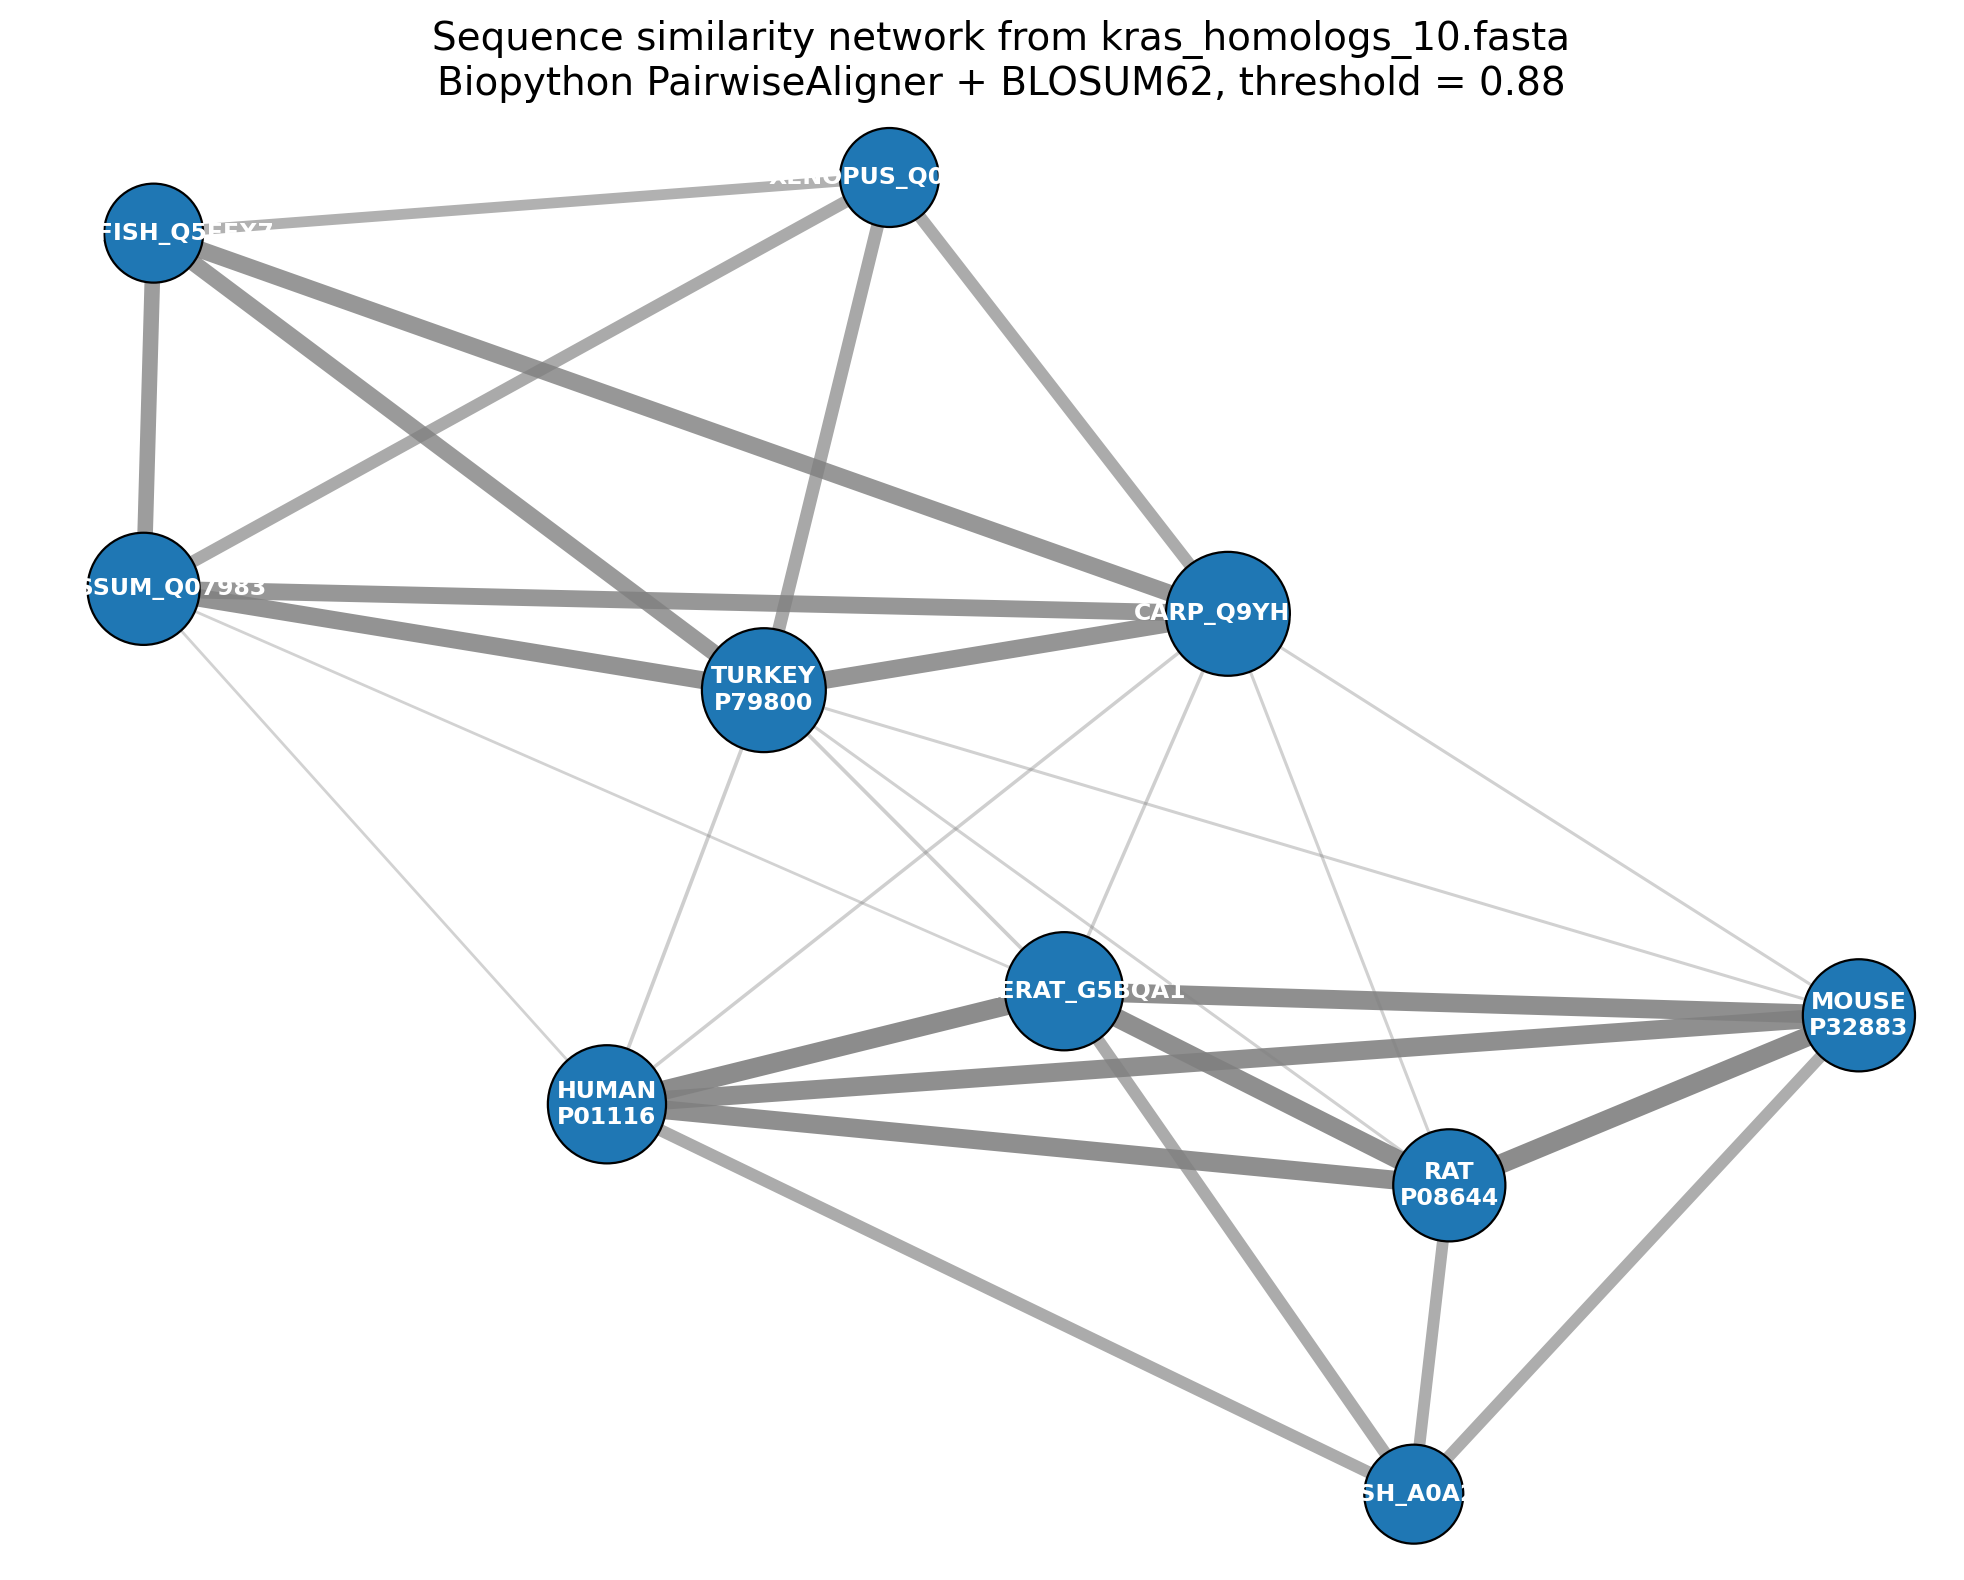

Saved figure: ../figures/sequenceTols_kras_ssn.png
Saved figure: ../figures/sequenceTols_kras_ssn.pdf


In [5]:
positions = nx.spring_layout(G, seed=7, weight='weight', k=1.1 / max(len(G), 2) ** 0.5, iterations=300)
component_palette = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e', '#8c564b', '#17becf', '#e377c2']
node_colors = [component_palette[(component_index[node] - 1) % len(component_palette)] for node in G.nodes()]
node_sizes = [550 + 180 * G.degree(node) for node in G.nodes()]
edge_widths = [1.0 + 6.0 * (data['weight'] - SIMILARITY_THRESHOLD) / max(1e-6, 1.0 - SIMILARITY_THRESHOLD) for _, _, data in G.edges(data=True)]
edge_alphas = [0.35 + 0.55 * (data['weight'] - SIMILARITY_THRESHOLD) / max(1e-6, 1.0 - SIMILARITY_THRESHOLD) for _, _, data in G.edges(data=True)]

fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
for (u, v, data), width, alpha in zip(G.edges(data=True), edge_widths, edge_alphas):
    x0, y0 = positions[u]
    x1, y1 = positions[v]
    ax.plot([x0, x1], [y0, y1], color='#808080', linewidth=width, alpha=alpha, zorder=1)

nx.draw_networkx_nodes(G, positions, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=0.8, ax=ax)
for node, (x_coord, y_coord) in positions.items():
    ax.text(x_coord, y_coord, short_label(node), ha='center', va='center', fontsize=8.5, color='white', fontweight='bold', zorder=3)

ax.set_title(
    f'Sequence similarity network from {INPUT_FASTA.name}\n'
    f'Biopython PairwiseAligner + BLOSUM62, threshold = {SIMILARITY_THRESHOLD:.2f}',
    fontsize=14,
)
ax.axis('off')
fig.tight_layout()
fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_PDF, bbox_inches='tight')
plt.show()

print(f'Saved figure: {OUTPUT_PNG}')
print(f'Saved figure: {OUTPUT_PDF}')


## Interpretation

An SSN is especially useful when the question is about **local neighborhoods** and **cluster structure** in sequence space rather than exact low-dimensional geometry. Connected components and dense subnetworks often highlight candidate subfamilies, iso-functional groups, or threshold-dependent transitions between them.

The graph depends strongly on the similarity definition and on the threshold. It should therefore be interpreted as a **filtered similarity graph**, not as a phylogenetic tree and not as a metric embedding.
